In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import numpy as np
from collections import defaultdict
import math

CT 1-1:

1: I read and print the first 5 and last 10 entries

2: I take all the dates from the earliest to most recent that can be found in the dataset. I then compare all the dates that exist in that span with the ones that exist in the dataset, filling the gaps with np.nan in the process.

3: The values get sorted

CT 1-2:

1: The chart shows that the lowest point for AMZN is around 5th of August 2024

2: While MSFT has a higher stock evaluation, the chart itself is fairly similar to the dips and highs of AMZN and GOOGL. Generally AAPL, GOOGL, TSLA and AMZN all look similar at the start, however the graphs diverge after around 1st of July. Thereafter, GOOGL and AMZN are similar to each other, and AAPL and TSLA are similar.

3: Frequency of 60 between 220-230

In [117]:
df: pd.DataFrame = pd.read_csv('./data/assignment_CaseA_data.csv')

dfList = [df.iloc[0:5], df.iloc[90:100]]

result: pd.DataFrame = pd.concat(dfList)

dates = mdates.drange(dt.datetime(2024, 5, 7), dt.datetime(2024, 9, 25), dt.timedelta(days=1))
dates_data = mdates.datestr2num(df['date'])

for date in dates:
    if date not in dates_data:
        df.loc[df.index.max() + 1] = [mdates.num2date(date).strftime('%Y-%m-%d'), np.nan, np.nan, np.nan, np.nan, np.nan]

df['date'] = pd.to_datetime(df['date'])
df['AAPL'] = pd.to_numeric(df['AAPL'])
df['MSFT'] = pd.to_numeric(df['MSFT'])
df['GOOGL'] = pd.to_numeric(df['GOOGL'])
df['TSLA'] = pd.to_numeric(df['TSLA'])
df['AMZN'] = pd.to_numeric(df['AMZN'])

df.sort_values(by=['date'], inplace=True)
date_data = mdates.date2num(df['date'])

df = df.interpolate(method='linear', inplace=True)
aapl_data = df['AAPL']
msft_data = df['MSFT']
googl_data = df['GOOGL']
amzn_data = df['AMZN']
tsla_data = df['TSLA']

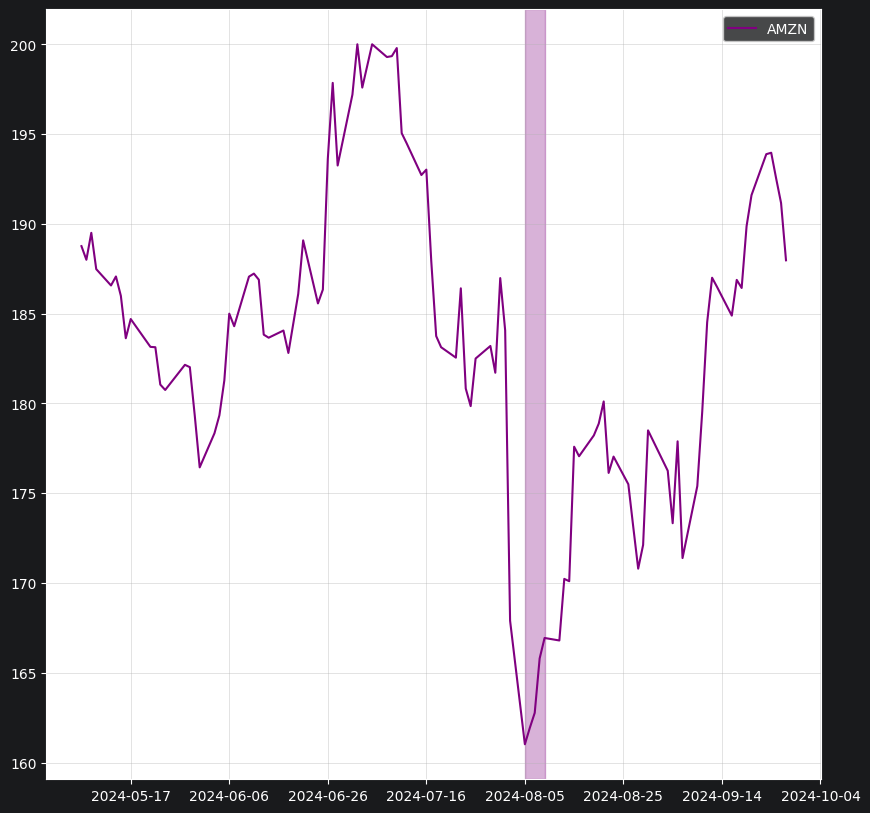

In [118]:
ax = plt.gca()
ax.set_facecolor('white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.grid()

plt.axvspan(*mdates.datestr2num(['2024-08-05', '2024-08-09']), color='purple', alpha=0.3)
plt.plot(date_data, amzn_data, color='purple', label='AMZN')
plt.legend()
plt.show()


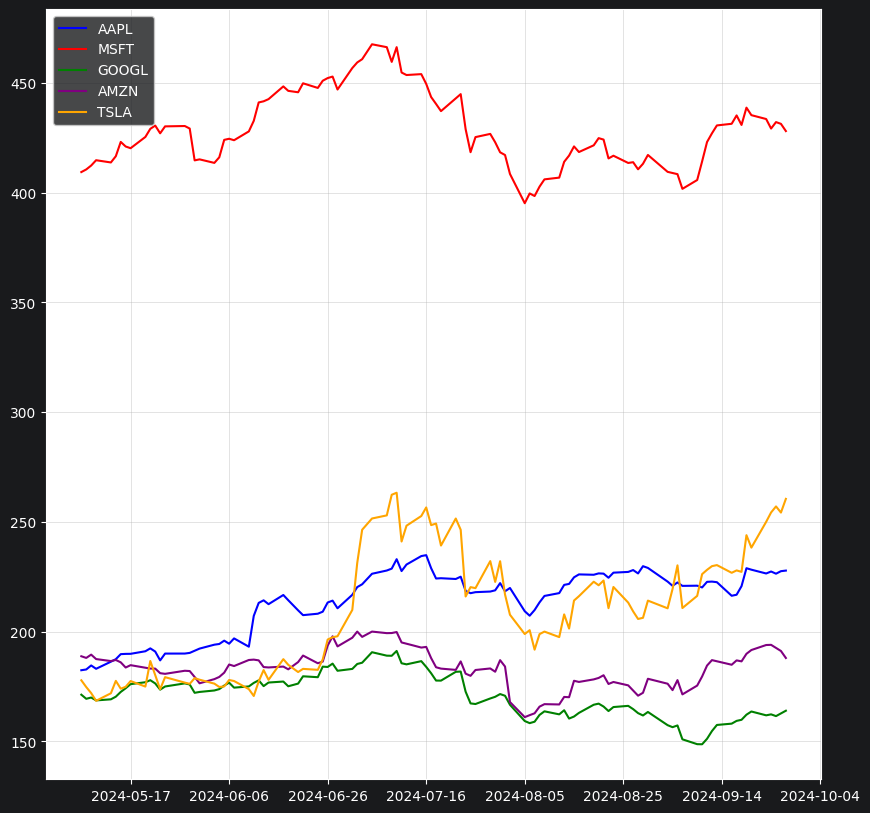

In [119]:
ax = plt.gca()
ax.set_facecolor('white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.grid()

plt.plot(date_data, aapl_data, color='blue', label='AAPL')
plt.plot(date_data, msft_data, color='red', label='MSFT')
plt.plot(date_data, googl_data, color='green', label='GOOGL')
plt.plot(date_data, amzn_data, color='purple', label='AMZN')
plt.plot(date_data, tsla_data, color='orange', label='TSLA')
plt.legend()
plt.show()


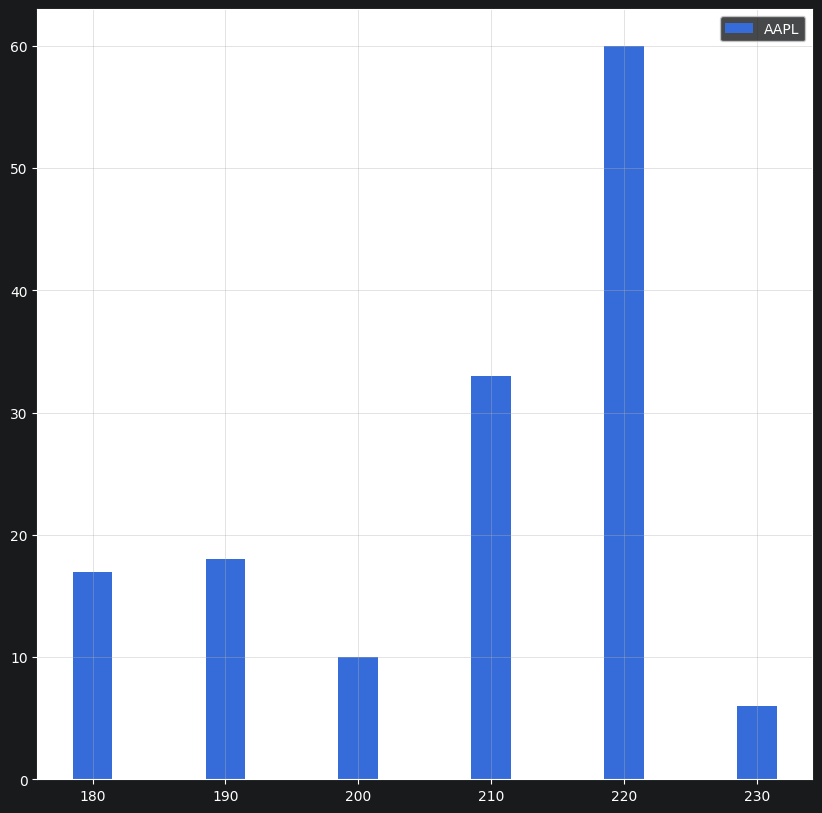

In [120]:
ax = plt.gca()
ax.set_facecolor('white')
plt.grid()

bucket: defaultdict = defaultdict(lambda: 0)
for num in aapl_data:

    if num is np.nan:
        continue

    num = math.floor(num / 10) * 10

    bucket[num] += 1

keys = bucket.keys()
vals = bucket.values()

plt.bar(keys, vals, label='AAPL', width=3.0)
plt.legend()
plt.show()
